# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

In [3]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [4]:
from utils import plot_pdf

In [5]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from YouTube.

The book puts first all theory and only after that we have a detailed example. To better understanding in this tutorial we have quotes from theory and examples together fallowing the sequence of commands

This example will not work for different vector sizes.

Size of vectors

In [9]:
d_num = 3
g_num = 2

In [10]:
b_degree = d_num + g_num - 1
b_degree

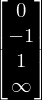

In [11]:
bi = [0, -1, 1, sy.oo]
# sy.Rational(1, 2)
sy.Matrix(bi)

Example of vectors for the convolution

In [12]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2]


Polynomial degree

In [13]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 1


In [14]:
x = sy.symbols("x")
x

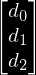

In [15]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

In [16]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

In [17]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

In [18]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

In [19]:
sx = gx*dx
sx

In [20]:
xi = [x**i for i in range(1, sy.degree(sx.expand(), x) + 1)]
xi

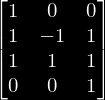

In [23]:
_a_mtx = [[(b **e) for e, d in enumerate(di)] for b in bi if b != sy.oo]
_a_inf = [[0] * (len(di) - 1) + [1]]
a_mtx = sy.Matrix(_a_mtx + _a_inf)
a_mtx

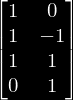

In [24]:
_b_mtx = [[(b **e) for e, d in enumerate(gi)] for b in bi if b != sy.oo]
_b_inf = [[0] * (len(gi) - 1) + [1]]
b_mtx = sy.Matrix(_b_mtx + _b_inf)
b_mtx

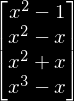

In [25]:
cd = [sy.expand(np.prod([(x - b) for b in i if b != sy.oo])) for i in itertools.combinations(reversed(bi), len(bi)-1)]
sy.Matrix(cd)

In [44]:
bi_inf = [x for x in bi if x != sy.oo]
bi_inf

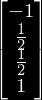

In [46]:
_cq = [
    1/sy.expand(np.prod([(b0 - b) for b in i]))
    for b0, i in 
    zip(bi_inf, itertools.combinations(reversed(bi_inf), len(bi_inf)-1))
]
cq = _cq + [1]
sy.Matrix(cq)

In [31]:
c0 = sy.Matrix([s.subs({x:0}) for s in cd])
c0.T

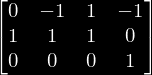

In [32]:
c1 = sy.Matrix([[d.coeff(c, 1) for c in xi] for d in cd])
c1.T

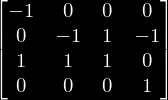

In [33]:
c_mtx = sy.Matrix(c0.T.tolist() + c1.T.tolist())
c_mtx

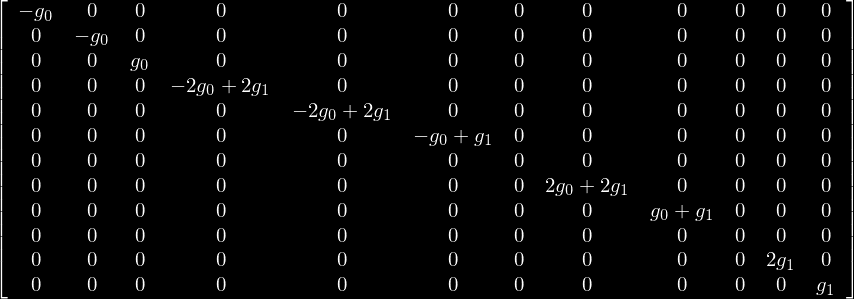

In [34]:
bg_mtx = sy.diag(*(sy.diag(*cq) * b_mtx * gi).tolist())
bg_mtx

In [35]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

ShapeError: ('Matrices are not aligned', 4, 12)

## Example

In [36]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

In [37]:
si = s.subs(subs)
si

NameError: name 's' is not defined

In [38]:
sy.expand(sx)

Let's compare the output polynomial matrix from direct and winograd method

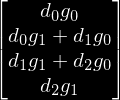

In [39]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

In [40]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

ShapeError: ('Matrices are not aligned', 4, 12)

Comparing numerical outputs from direct and winograd method

In [41]:
sy.Matrix(np.convolve(d_values, g_values))

In [42]:
se.subs(subs)

NameError: name 'se' is not defined